# MultiWeather-ThermalUAV — Segmentation Experiments

**Models:** U-Net · LR-ASPP MobileNetV3-Large  
**Modalities:** RGB · Thermal · Fusion  
**Weather:** Clear · Fog · Rain · Snow  
**Classes:** Horizontal (0) · Vertical (1) · Other (2)

## Requirements
```bash
pip install torch torchvision opencv-python numpy pandas matplotlib
```

## Usage
Run cells top to bottom. Results are saved automatically to 
`experiment_results/`. Training takes approximately 3-4 hours on 
Apple MPS hardware.

## Data
Download the dataset from Hugging Face and place it at:
`MultiWeather-ThermalUAV/final_dataset/`

In [4]:
import os
import random
import time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torchvision.models.segmentation as seg_models
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset

# ------------------------------------------------
# Reproducibility
# ------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------
# Config
# ------------------------------------------------
DATA_ROOT   = "MultiWeather-ThermalUAV/final_dataset"
RESULTS_DIR = "experiment_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

NUM_CLASSES = 3
CLASS_NAMES = ["Horizontal", "Vertical", "Other"]
WEATHERS    = ["clear", "fog", "rain", "snow"]
MODALITIES  = ["rgb", "thermal", "fusion"]
IMG_SIZE    = 256
BATCH_SIZE  = 8

DEVICE = torch.device("mps"  if torch.backends.mps.is_available() else
                       "cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
print(f"Data   : {DATA_ROOT}")
print(f"Output : {RESULTS_DIR}")

Device : mps
Data   : MultiWeather-ThermalUAV/final_dataset
Output : experiment_results


In [5]:
class MultiWeatherDataset(Dataset):
    """
    Loads RGB, Thermal, or Fusion (RGB+Thermal) samples
    from the MultiWeather-ThermalUAV final_dataset.

    modality: 'rgb' | 'thermal' | 'fusion'
    """

    # ImageNet stats for pretrained backbone normalisation
    RGB_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    RGB_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, root, split, weather, modality):
        self.base     = os.path.join(root, split, weather)
        self.modality = modality
        self.files    = sorted(os.listdir(os.path.join(self.base, "rgb")))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname  = self.files[idx]
        inputs = []

        if self.modality in ["rgb", "fusion"]:
            rgb = cv2.imread(os.path.join(self.base, "rgb", fname))
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            rgb = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
            rgb = rgb.astype(np.float32) / 255.0
            rgb = (rgb - self.RGB_MEAN) / self.RGB_STD
            inputs.append(rgb.transpose(2, 0, 1))   # 3,H,W

        if self.modality in ["thermal", "fusion"]:
            th = cv2.imread(
                os.path.join(self.base, "thermal", fname),
                cv2.IMREAD_UNCHANGED)
            th = cv2.resize(th, (IMG_SIZE, IMG_SIZE))
            th = th.astype(np.float32) / 65535.0     # 16-bit normalisation
            inputs.append(th[np.newaxis])             # 1,H,W

        x = np.concatenate(inputs, axis=0)

        mask = cv2.imread(
            os.path.join(self.base, "masks", fname),
            cv2.IMREAD_UNCHANGED)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                          interpolation=cv2.INTER_NEAREST)

        return (torch.tensor(x,    dtype=torch.float32),
                torch.tensor(mask, dtype=torch.long))


# Quick sanity check
for mod in ["rgb", "thermal", "fusion"]:
    ds = MultiWeatherDataset(DATA_ROOT, "train", "clear", mod)
    x, y = ds[0]
    print(f"{mod:8s} — x: {tuple(x.shape)}  y: {tuple(y.shape)}  "
          f"classes: {y.unique().tolist()}")

rgb      — x: (3, 256, 256)  y: (256, 256)  classes: [0, 1, 2]
thermal  — x: (1, 256, 256)  y: (256, 256)  classes: [0, 1, 2]
fusion   — x: (4, 256, 256)  y: (256, 256)  classes: [0, 1, 2]


In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    """
    Lightweight U-Net with 4 encoder levels and BatchNorm.
    Trained from scratch for all modalities.
    """
    def __init__(self, in_channels, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)
        self.up1  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec1 = DoubleConv(256, 128)
        self.up2  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up3  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec3 = DoubleConv(64, 32)
        self.final = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))
        d1 = self.dec1(torch.cat([self.up1(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d1), e2], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d2), e1], dim=1))
        return self.final(d3)


# Verify
for in_ch, mod in [(3, "rgb"), (1, "thermal"), (4, "fusion")]:
    m = UNet(in_ch)
    x = torch.randn(2, in_ch, 256, 256)
    print(f"UNet {mod:8s} — output: {tuple(m(x).shape)}")

UNet rgb      — output: (2, 3, 256, 256)
UNet thermal  — output: (2, 3, 256, 256)
UNet fusion   — output: (2, 3, 256, 256)


In [7]:
def build_lraspp(modality, num_classes=NUM_CLASSES):
    """
    LR-ASPP MobileNetV3-Large.
    RGB   : pretrained ImageNet weights, first conv unchanged.
    Others: pretrained weights, first conv adapted via weight averaging.
            This preserves pretrained feature knowledge while
            accepting non-RGB input channels.
    """
    in_channels = {"rgb": 3, "thermal": 1, "fusion": 4}[modality]

    # Always start from pretrained weights
    model = seg_models.lraspp_mobilenet_v3_large(
        weights=seg_models.LRASPP_MobileNet_V3_Large_Weights.DEFAULT)

    # Replace classifier head for our number of classes
    model.classifier.low_classifier  = nn.Conv2d(40,  num_classes, 1)
    model.classifier.high_classifier = nn.Conv2d(128, num_classes, 1)

    if modality != "rgb":
        old_conv = model.backbone["0"][0]
        new_conv = nn.Conv2d(
            in_channels,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
        with torch.no_grad():
            if modality == "thermal":
                # Average RGB pretrained weights into single channel
                new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)
            elif modality == "fusion":
                # RGB channels keep pretrained weights
                # Thermal channel initialised as average of RGB weights
                new_conv.weight[:, :3, :, :] = old_conv.weight
                new_conv.weight[:, 3:, :, :] = old_conv.weight.mean(
                    dim=1, keepdim=True)
        model.backbone["0"][0] = new_conv

    return model


# Verify
for mod in ["rgb", "thermal", "fusion"]:
    in_ch = {"rgb": 3, "thermal": 1, "fusion": 4}[mod]
    m = build_lraspp(mod).eval()
    x = torch.randn(2, in_ch, 256, 256)
    with torch.no_grad():
        out = m(x)["out"]
    preds = torch.argmax(out, dim=1).unique().tolist()
    print(f"LR-ASPP {mod:8s} — output: {tuple(out.shape)}  "
          f"predicted classes: {preds}")

LR-ASPP rgb      — output: (2, 3, 256, 256)  predicted classes: [0, 1, 2]
LR-ASPP thermal  — output: (2, 3, 256, 256)  predicted classes: [0, 2]
LR-ASPP fusion   — output: (2, 3, 256, 256)  predicted classes: [1]


In [11]:
# ------------------------------------------------
# Class weights based on inverse frequency
# Computed from 500 training masks
# Class 0 (Horizontal) : 50.6%
# Class 1 (Vertical)   : 10.7%
# Class 2 (Other)      : 38.7%
# ------------------------------------------------
CLASS_WEIGHTS = torch.tensor([0.428, 2.013, 0.559], dtype=torch.float32)

def forward_pass(model, x):
    """Handles both UNet (tensor) and LR-ASPP (dict) outputs."""
    out = model(x)
    return out["out"] if isinstance(out, dict) else out


def train_one_epoch(model, loader, optimiser, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(forward_pass(model, x), y)
        loss.backward()
        optimiser.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    """Returns mean IoU and per-class IoU."""
    model.eval()
    inter = np.zeros(NUM_CLASSES)
    union = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = torch.argmax(forward_pass(model, x), dim=1)
            for c in range(NUM_CLASSES):
                inter[c] += ((preds == c) & (y == c)).sum().item()
                union[c] += ((preds == c) | (y == c)).sum().item()

    per_class = [inter[c] / union[c] if union[c] > 0 else 0.0
                 for c in range(NUM_CLASSES)]
    return {
        "miou":      float(np.mean(per_class)),
        "per_class": [round(v, 4) for v in per_class]
    }


def run_experiment(model_name, modality, epochs,
                   train_ds, val_ds, patience=5):
    print(f"\n{'='*55}")
    print(f"  {model_name.upper()} | {modality.upper()}")
    print(f"{'='*55}")

    in_ch     = {"rgb": 3, "thermal": 1, "fusion": 4}[modality]
    model     = (UNet(in_ch) if model_name == "unet"
                 else build_lraspp(modality)).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(
                    optimiser, step_size=8, gamma=0.5)

    # Weighted loss to handle class imbalance
    criterion = nn.CrossEntropyLoss(
                    weight=CLASS_WEIGHTS.to(DEVICE))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0)

    best_miou  = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        t0   = time.time()
        loss = train_one_epoch(model, train_loader, optimiser, criterion)
        val  = evaluate(model, val_loader)
        scheduler.step()
        elapsed = time.time() - t0

        print(f"  Epoch {epoch:02d}/{epochs} | "
              f"loss: {loss:.4f} | "
              f"val mIoU: {val['miou']:.4f} | "
              f"per-class: {val['per_class']} | "
              f"{elapsed:.0f}s")

        if val["miou"] > best_miou:
            best_miou  = val["miou"]
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    # Save best checkpoint
    ckpt_path = os.path.join(
        RESULTS_DIR, f"{model_name}_{modality}_best.pt")
    torch.save(best_state, ckpt_path)
    print(f"  Best val mIoU: {best_miou:.4f} — saved to {ckpt_path}")

    # Reload best weights
    model.load_state_dict(best_state)

    # Test on all weather conditions
    results = {"model": model_name, "modality": modality}
    print(f"\n  Test results:")
    for w in WEATHERS:
        test_ds     = MultiWeatherDataset(DATA_ROOT, "test", w, modality)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                                 shuffle=False, num_workers=0)
        r = evaluate(model, test_loader)
        results[w]                = round(r["miou"], 4)
        results[f"{w}_per_class"] = r["per_class"]
        print(f"    {w:6s}: mIoU={r['miou']:.4f} | "
              f"per-class={r['per_class']}")

    return results


print("Functions defined with weighted loss.")
print(f"Class weights: {CLASS_WEIGHTS.tolist()}")

Functions defined with weighted loss.
Class weights: [0.42800000309944153, 2.013000011444092, 0.5590000152587891]


In [18]:
def forward_pass(model, x):
    out = model(x)
    return out["out"] if isinstance(out, dict) else out


def train_one_epoch(model, loader, optimiser, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(forward_pass(model, x), y)
        loss.backward()
        optimiser.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    inter = np.zeros(NUM_CLASSES)
    union = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = torch.argmax(forward_pass(model, x), dim=1)
            for c in range(NUM_CLASSES):
                inter[c] += ((preds == c) & (y == c)).sum().item()
                union[c] += ((preds == c) | (y == c)).sum().item()

    per_class = [inter[c] / union[c] if union[c] > 0 else 0.0
                 for c in range(NUM_CLASSES)]
    return {
        "miou":      float(np.mean(per_class)),
        "per_class": [round(v, 4) for v in per_class]
    }


def run_experiment(model_name, modality):
    print(f"\n{'='*55}")
    print(f"  {model_name.upper()} | {modality.upper()}")
    print(f"  Started: {time.strftime('%H:%M:%S')}")
    print(f"{'='*55}")

    in_ch     = {"rgb": 3, "thermal": 1, "fusion": 4}[modality]
    model     = (UNet(in_ch) if model_name == "unet"
                 else build_lraspp(modality)).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(
                    optimiser, step_size=8, gamma=0.5)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE))

    train_ds = MultiWeatherDataset(DATA_ROOT, "train", "clear", modality)
    val_ds   = MultiWeatherDataset(DATA_ROOT, "val",   "clear", modality)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0)

    best_miou  = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        t0   = time.time()
        loss = train_one_epoch(model, train_loader, optimiser, criterion)
        val  = evaluate(model, val_loader)
        scheduler.step()
        elapsed = time.time() - t0

        print(f"  Epoch {epoch:02d}/{EPOCHS} | "
              f"loss: {loss:.4f} | "
              f"val mIoU: {val['miou']:.4f} | "
              f"per-class: {val['per_class']} | "
              f"{elapsed:.0f}s")

        if val["miou"] > best_miou:
            best_miou  = val["miou"]
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

    ckpt_path = os.path.join(RESULTS_DIR,
                             f"{model_name}_{modality}_best.pt")
    torch.save(best_state, ckpt_path)
    print(f"  Best val mIoU: {best_miou:.4f} — saved to {ckpt_path}")

    model.load_state_dict(best_state)

    results = {"model": model_name, "modality": modality}
    print(f"\n  Test results:")
    for w in WEATHERS:
        test_ds     = MultiWeatherDataset(DATA_ROOT, "test", w, modality)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                                 shuffle=False, num_workers=0)
        r = evaluate(model, test_loader)
        results[w]                = round(r["miou"], 4)
        results[f"{w}_per_class"] = r["per_class"]
        print(f"    {w:6s}: mIoU={r['miou']:.4f} | "
              f"per-class={r['per_class']}")

    return results

print("All functions ready.")

All functions ready.


In [19]:
patience = PATIENCE

print("="*55)
print("STAGE 2: FULL OVERNIGHT RUN")
print(f"Started: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*55)

start_total = time.time()
all_results = []

for modality in MODALITIES:
    for model_name in ["unet", "lraspp"]:
        res = run_experiment(model_name, modality)
        all_results.append(res)

        # Save results after every experiment
        # so if something crashes you keep what ran
        df_interim = pd.DataFrame(all_results)
        df_interim.to_csv(
            os.path.join(RESULTS_DIR, "results_interim.csv"),
            index=False)

total_hours = (time.time() - start_total) / 3600
print(f"\n{'='*55}")
print(f"ALL EXPERIMENTS COMPLETE")
print(f"Finished: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total time: {total_hours:.2f} hours")
print(f"{'='*55}")

STAGE 2: FULL OVERNIGHT RUN
Started: 2026-03-27 22:36:34

  UNET | RGB
  Started: 22:36:34
  Epoch 01/25 | loss: 0.7390 | val mIoU: 0.4246 | per-class: [np.float64(0.5025), np.float64(0.393), np.float64(0.3782)] | 346s
  Epoch 02/25 | loss: 0.6667 | val mIoU: 0.4549 | per-class: [np.float64(0.5384), np.float64(0.408), np.float64(0.4183)] | 351s
  Epoch 03/25 | loss: 0.6214 | val mIoU: 0.5067 | per-class: [np.float64(0.5855), np.float64(0.4614), np.float64(0.4731)] | 346s
  Epoch 04/25 | loss: 0.5918 | val mIoU: 0.5287 | per-class: [np.float64(0.6288), np.float64(0.4873), np.float64(0.4701)] | 348s
  Epoch 05/25 | loss: 0.5698 | val mIoU: 0.5405 | per-class: [np.float64(0.6145), np.float64(0.5054), np.float64(0.5016)] | 349s
  Epoch 06/25 | loss: 0.5541 | val mIoU: 0.5487 | per-class: [np.float64(0.6364), np.float64(0.5078), np.float64(0.5019)] | 348s
  Epoch 07/25 | loss: 0.5425 | val mIoU: 0.5379 | per-class: [np.float64(0.6193), np.float64(0.5055), np.float64(0.4888)] | 345s
  Epoch 

FINAL RESULTS (mIoU)
 model modality  clear    fog   rain   snow
  unet      rgb 0.6067 0.3720 0.3324 0.5843
lraspp      rgb 0.5511 0.3845 0.4245 0.5430
  unet  thermal 0.5573 0.4252 0.5321 0.5551
lraspp  thermal 0.5240 0.4588 0.5153 0.5236
  unet   fusion 0.7206 0.2385 0.2961 0.4793
lraspp   fusion 0.6380 0.1885 0.3039 0.5577


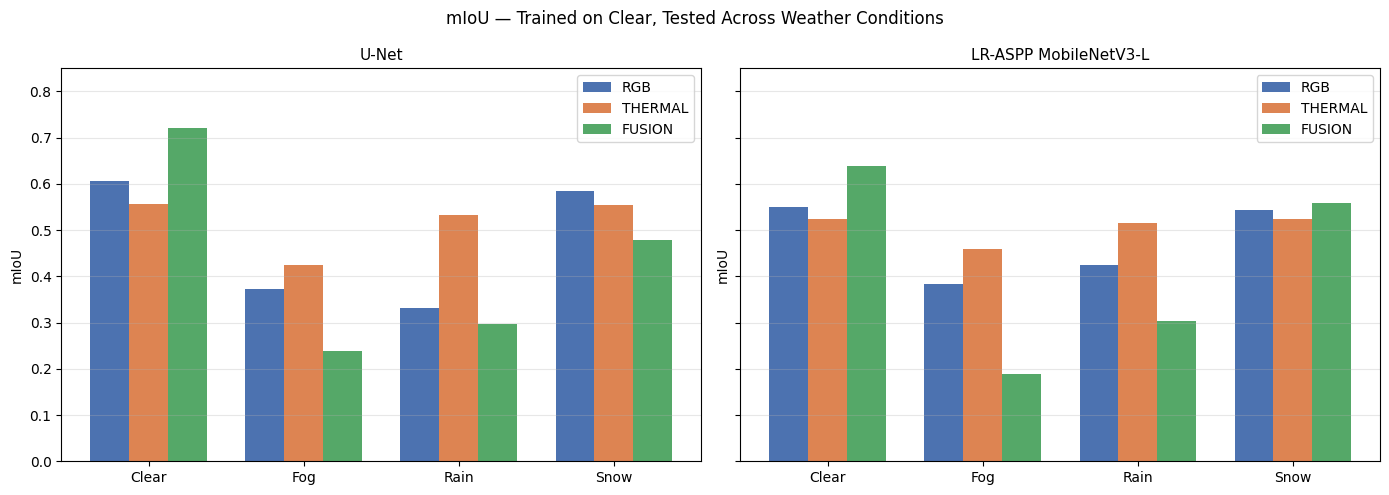

Saved: experiment_results/results_bar.png


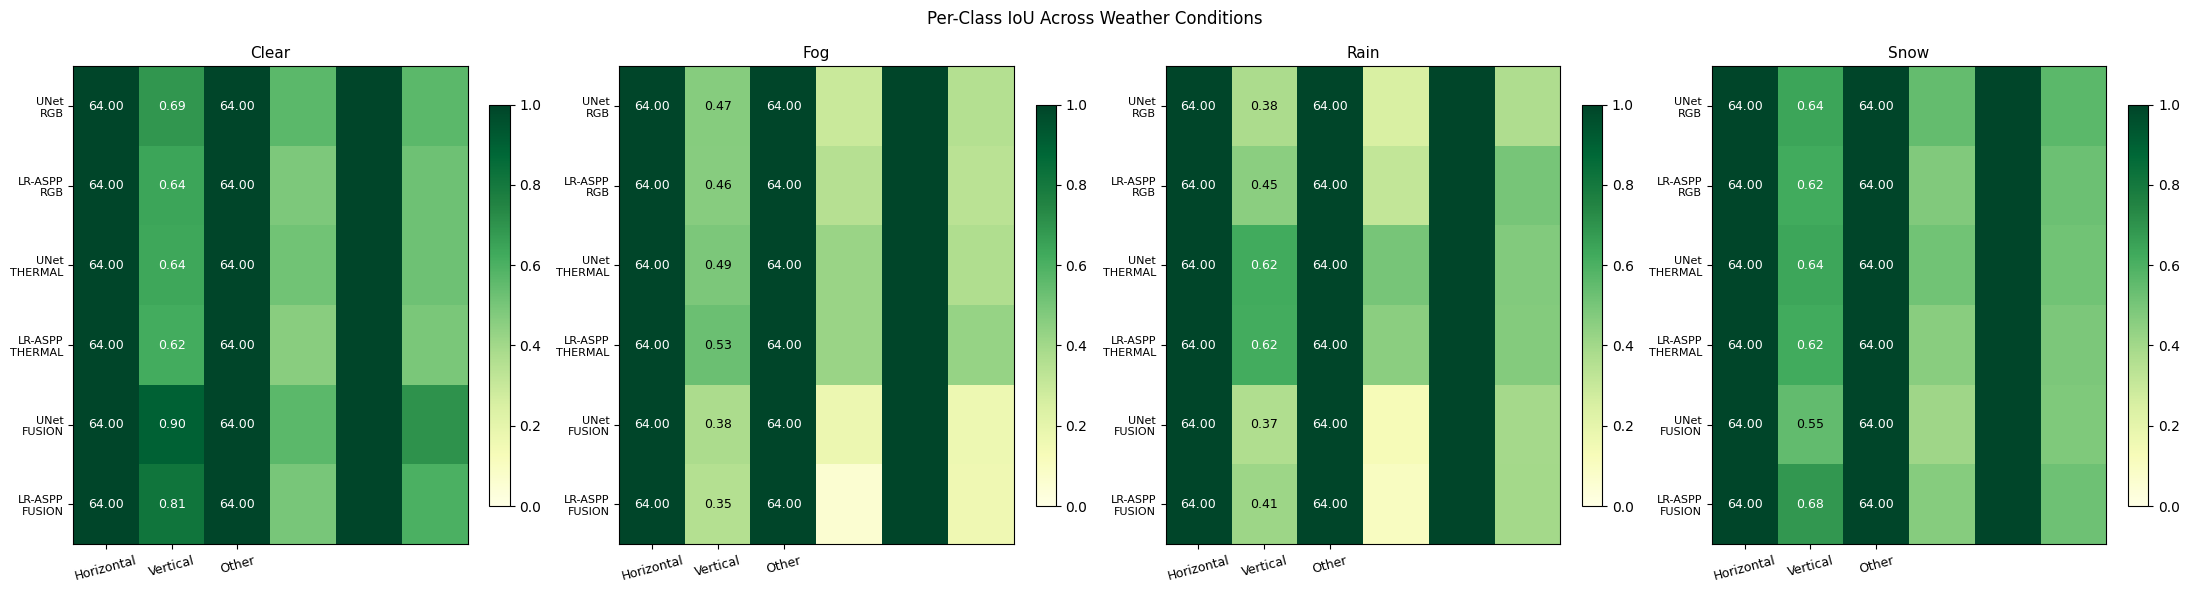

Saved: experiment_results/per_class_heatmap.png

Done. Share results_final.csv and both plots.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

RESULTS_DIR = "experiment_results"
CLASS_NAMES = ["Horizontal", "Vertical", "Other"]
WEATHERS    = ["clear", "fog", "rain", "snow"]
MODALITIES  = ["rgb", "thermal", "fusion"]

def parse_per_class(val):
    """Strips np.float64(...) wrappers and parses the list."""
    if isinstance(val, list):
        return val
    val = str(val)
    numbers = re.findall(r"[-+]?\d*\.?\d+", val)
    return [float(n) for n in numbers]

# Load results
df = pd.read_csv(os.path.join(RESULTS_DIR, "results_interim.csv"))
cols = ["model", "modality"] + WEATHERS
print("FINAL RESULTS (mIoU)")
print("="*55)
print(df[cols].to_string(index=False))

df[cols].to_csv(os.path.join(RESULTS_DIR, "results_final.csv"), index=False)

# ------------------------------------------------
# Plot 1: Bar chart
# ------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle(
    "mIoU — Trained on Clear, Tested Across Weather Conditions",
    fontsize=12)

colours = {"rgb": "#4C72B0", "thermal": "#DD8452", "fusion": "#55A868"}

for ax, model_name in zip(axes, ["unet", "lraspp"]):
    subset = df[df["model"] == model_name]
    x      = np.arange(len(WEATHERS))
    width  = 0.25

    for i, mod in enumerate(MODALITIES):
        row  = subset[subset["modality"] == mod]
        if len(row) == 0:
            continue
        vals = [float(row[w].values[0]) for w in WEATHERS]
        ax.bar(x + i * width, vals, width,
               label=mod.upper(), color=colours[mod])

    title = "U-Net" if model_name == "unet" else "LR-ASPP MobileNetV3-L"
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x + width)
    ax.set_xticklabels([w.capitalize() for w in WEATHERS])
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
bar_path = os.path.join(RESULTS_DIR, "results_bar.png")
plt.savefig(bar_path, dpi=150)
plt.show()
print(f"Saved: {bar_path}")

# ------------------------------------------------
# Plot 2: Per-class IoU heatmap
# ------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("Per-Class IoU Across Weather Conditions", fontsize=12)

for ax, w in zip(axes, WEATHERS):
    matrix  = []
    ylabels = []

    for _, row in df.iterrows():
        key = f"{w}_per_class"
        if key in df.columns:
            val = parse_per_class(row[key])
            matrix.append(val)
            model_label = "UNet" if row["model"] == "unet" else "LR-ASPP"
            ylabels.append(f"{model_label}\n{row['modality'].upper()}")

    matrix = np.array(matrix)
    im = ax.imshow(matrix, vmin=0, vmax=1, cmap="YlGn", aspect="auto")
    ax.set_title(w.capitalize(), fontsize=11)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=15, fontsize=9)
    ax.set_yticks(range(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=8)

    for i in range(len(ylabels)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center", fontsize=9,
                    color="black" if matrix[i, j] < 0.6 else "white")

    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
heatmap_path = os.path.join(RESULTS_DIR, "per_class_heatmap.png")
plt.savefig(heatmap_path, dpi=150)
plt.show()
print(f"Saved: {heatmap_path}")

print("\nDone. Share results_final.csv and both plots.")